<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [2]:
# Import Libraries (pandas, numpy, matplotlib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Data

We will use retail data for time-series modeling. 

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________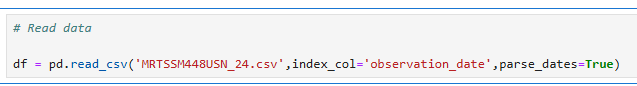

In [4]:
df =pd.read_csv('MRTSSM448USN_24.csv' , index_col='observation_date' , parse_dates=True)

In [ ]:
#pd.read_csv

In [5]:
# Print the first few rows of data
df.head()
# ...

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________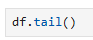

In [6]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [11]:
# Set name of column as 'Sales'. Use - df.columns 
# Check column names and rename if necessary
print("Original columns:", df.columns)

# If the column has no name or is something else, set it to 'Sales'
if df.columns[0] != 'Sales':
    df.columns = ['Sales']
    print("Column renamed to 'Sales'.")
else:
    print("Column already named 'Sales'.")

Original columns: Index(['Sales'], dtype='str')
Column already named 'Sales'.


In [14]:
df.tail()

,Sales
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________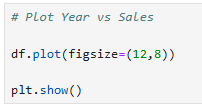

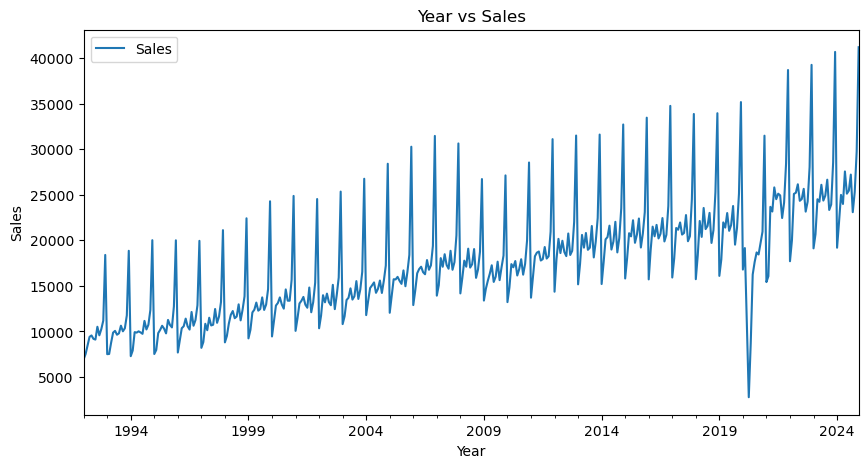

In [15]:
# Plot sales data over time
df.plot(figsize=(10,5))
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Year vs Sales')
plt.show()

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________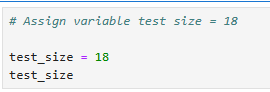

In [16]:
test_size = 18
test_size

18

__________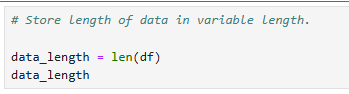

In [17]:
data_length = len(df)
data_length

396

__________________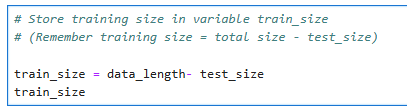

In [18]:
train_size = data_length - test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________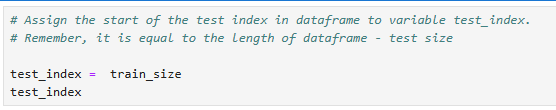

In [19]:
test_index = train_size
test_index  

378

Next, we will separate train and test datasets.

_________________________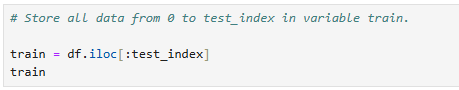

In [21]:
train  = df.iloc[:test_index]
train

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [22]:
# Store everything from test_index to the last sample in the test variable 
# Hint - Use df.iloc

test = df.iloc[test_index:]

In [23]:
print("Size of train data:", len(train))
print("Size of test data:", len(test))

Size of train data: 378
Size of test data: 18


### In Neural Networks, we need to Scale Data between 0-1

___________________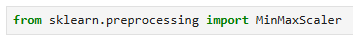

In [24]:
from sklearn.preprocessing import MinMaxScaler

_______________________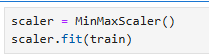

In [25]:
scaler = MinMaxScaler()
scaler.fit(train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


__________________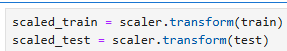

In [26]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [27]:
# Check if the data has been scaled properly
# Print max and min for train and test

print("Scaled train max:", scaled_train.max())
print("Scaled train min:", scaled_train.min())
print("Scaled test max:", scaled_test.max())
print("Scaled test min:", scaled_test.min())

Scaled train max: 1.0
Scaled train min: 0.0
Scaled test max: 1.0530599939704552
Scaled test min: 0.44980403979499545


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


_____________________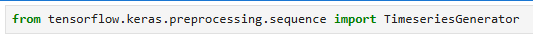

In [28]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

c:\Users\Eranga\anaconda3\envs\ai-image-publisher\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [29]:
TimeseriesGenerator?

Init signature:
TimeseriesGenerator(
    data,
    targets,
    length,
    sampling_rate=1,
    stride=1,
    start_index=0,
    end_index=None,
    shuffle=False,
    reverse=False,
    batch_size=128,
    **kwargs,
)
Docstring:     
Utility class for generating batches of temporal data.

DEPRECATED.

This class takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

Arguments:
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, ti

_________________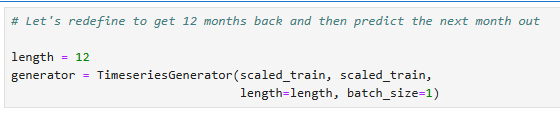

In [30]:
length =12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)

_______________________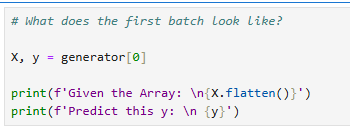

In [31]:
X ,y = generator[0]
print(f'Given the Array: \n{X.flatten()} \nThe corresponding label is: {y}')

Given the Array: 
[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027] 
The corresponding label is: [[0.12952558]]


### Create the Model

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import GRU

import tensorflow as tf

________________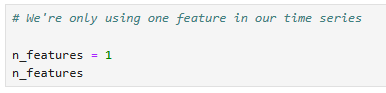

In [33]:
n_features = 1
n_features

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [34]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task

model = Sequential()
model.add(SimpleRNN(50, input_shape=(length, n_features)))
model.add(Dense(1))

c:\Users\Eranga\anaconda3\envs\ai-image-publisher\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

_____________________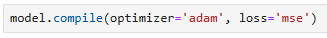

In [37]:
model.compile(optimizer='adam', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 2 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [38]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, 
                                           length=length, batch_size=1)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

In [42]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# If the last digit of your SID = 0, then assign patience=10
# For example, your SID = 22984879, then patience=9

LAST_DIGIT_IN_YOUR_SID = 5

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)

_____________________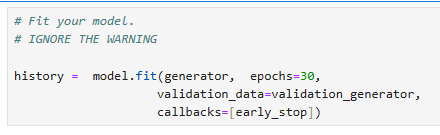

In [43]:
history = model.fit(generator, epochs=30, validation_data=validation_generator,  callbacks=[early_stop])

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0107 - val_loss: 0.0047
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0070 - val_loss: 0.0028
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0071 - val_loss: 0.0039
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067 - val_loss: 0.0080
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0067 - val_loss: 0.0095
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0065 - val_loss: 0.0079
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0058 - val_loss: 0.0213
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - val_loss: 0.0167
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0061 - val_loss: 0.0078
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 12/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

_____________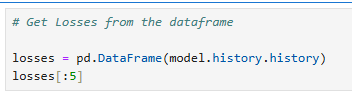

In [45]:
losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.010728,0.004683
1,0.007028,0.002761
2,0.007074,0.003923
3,0.006413,0.005640
4,0.006696,0.007992


In [124]:
# the values may be different


___________________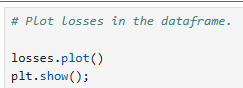

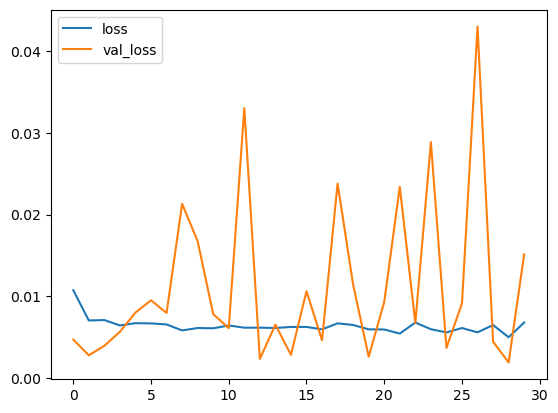

In [46]:
losses.plot()
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

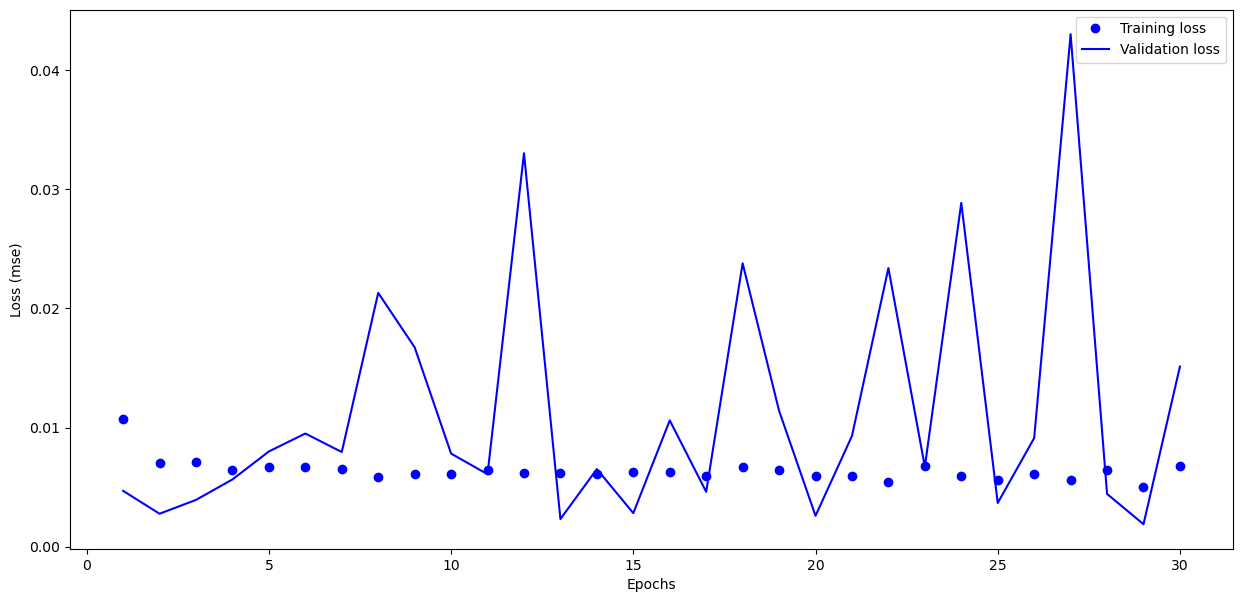

In [47]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________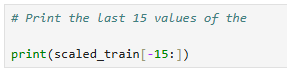

In [48]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________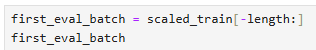

In [49]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [50]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________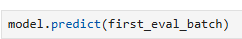

In [51]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


array([[0.5789974]], dtype=float32)

_________________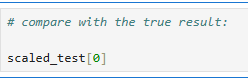

In [52]:
scaled_test[0]

array([0.60665442])

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the 3 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [53]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

In [54]:
for i in range(len(test)):
    
    # get prediction 1 time stamp ahead ([0] is for 
    # grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    test_predictions.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [55]:
test_predictions

[array([0.5789974], dtype=float32),
 array([0.59957474], dtype=float32),
 array([0.5222023], dtype=float32),
 array([0.5359975], dtype=float32),
 array([0.5468589], dtype=float32),
 array([0.78294253], dtype=float32),
 array([0.53896546], dtype=float32),
 array([0.50275517], dtype=float32),
 array([0.5604199], dtype=float32),
 array([0.56898737], dtype=float32),
 array([0.5851958], dtype=float32),
 array([0.5691551], dtype=float32),
 array([0.5624119], dtype=float32),
 array([0.5900637], dtype=float32),
 array([0.5283885], dtype=float32),
 array([0.5326681], dtype=float32),
 array([0.50740695], dtype=float32),
 array([0.66277635], dtype=float32)]

### Inverse Transformations and Compare

_________________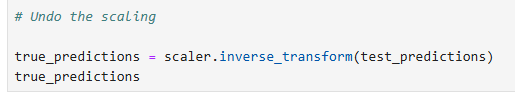

In [56]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[23901.87716985],
       [24652.68370992],
       [21829.59579247],
       [22332.94114578],
       [22729.24093044],
       [31343.22421956],
       [22441.23287177],
       [21120.02770901],
       [23224.04151547],
       [23536.64215231],
       [24128.03841758],
       [23542.76202452],
       [23296.72315347],
       [24305.6538986 ],
       [22055.31120729],
       [22211.46146488],
       [21289.75738454],
       [26958.72071803]])

_____________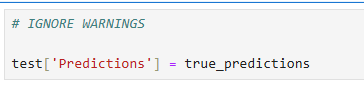

In [57]:
test['Predictions'] = true_predictions

### Check and plot predictions

In [58]:
# Print the test variable

test


,Sales,Predictions
observation_date,,
2023-07-01,24911,23901.877170
2023-08-01,26657,24652.683710
2023-09-01,23332,21829.595792
2023-10-01,23933,22332.941146
2023-11-01,28580,22729.240930
2023-12-01,40684,31343.224220
2024-01-01,19188,22441.232872
2024-02-01,22005,21120.027709
2024-03-01,24986,23224.041515


_______________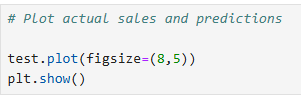

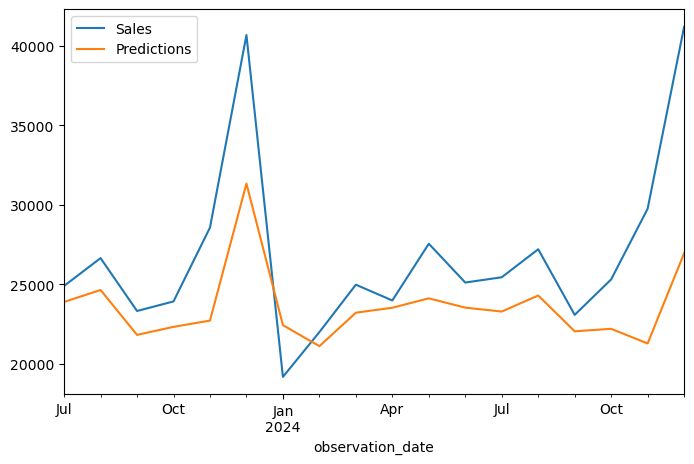

In [60]:
test.plot(figsize=(8,5))
plt.show()

### Retrain and Forecasting

<html> <h4 style="font-style:italic; color:blue;"> Just run the 3 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [61]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

In [63]:
print(scaled_full_data.max())
print(scaled_full_data.min())

1.0
0.0


In [64]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, 
                                scaled_full_data, length=length, batch_size=1)

In [67]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model


model = Sequential()
model.add(SimpleRNN(50, input_shape=(length, n_features)))
model.add(Dense(1))

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [90]:
model.summary()

Model: "sequential_3"

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,955 (31.08 KB)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,955 (31.08 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,955 (31.08 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,304 (20.72 KB)

In [69]:
# your code to compile the model


model.compile(optimizer='adam', loss='mse')

In [202]:
model.compile(optimizer='adam', loss='mse')

In [70]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# If the last digit of your SID = 0, then assign patience=10
# For example, your SID = 22984879, then patience=9

LAST_DIGIT_IN_YOUR_SID = 5

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


____________________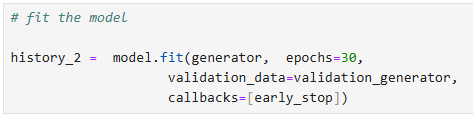

In [73]:
history_2 = model.fit(generator, epochs=30, validation_data=validation_generator,  callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0052 - val_loss: 0.0025
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0068
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0045 - val_loss: 0.0051
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0055 - val_loss: 0.0045
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0054 - val_loss: 0.0012
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0052 - val_loss: 0.0100
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0050 - val_loss: 0.0017
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - val_loss: 0.0019
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0120
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0047 - val_loss: 0.0061
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0053 - val_loss: 0.0044
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [92]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0037
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0063
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - val_loss: 0.0081
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0046


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

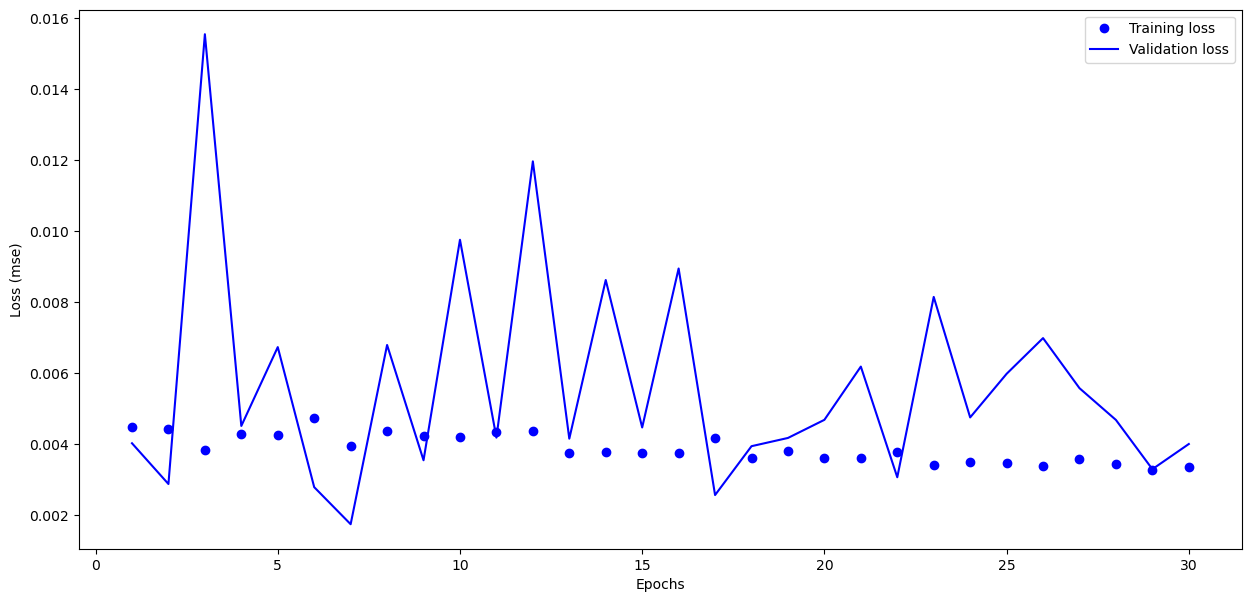

In [91]:
# print Loss for the neural network training process

history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [215]:
# You can use the code created above to type the next cell code

_________________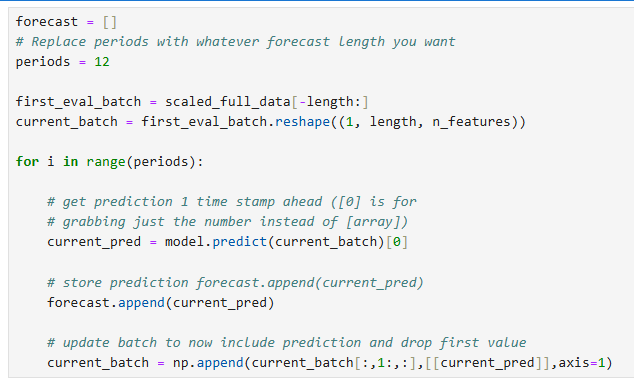

In [77]:
forecast = []
periods = 12

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred) 
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)    
    


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


______________________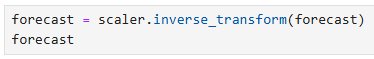

In [78]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[20138.08834058],
       [22831.26924777],
       [25383.18854171],
       [24154.81014001],
       [27113.53565168],
       [24938.48435199],
       [26566.51389694],
       [27265.93438846],
       [21699.17553067],
       [23010.0634675 ],
       [30370.35157013],
       [36102.93199742]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [79]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


In [80]:
forecast_index = pd.date_range(start='2025-01-01',periods=periods,freq='MS')

In [81]:
forecast_df = pd.DataFrame(data=forecast,index=forecast_index,
                           columns=['Forecast'])

In [82]:
forecast_df

,Forecast
2025-01-01,20138.088341
2025-02-01,22831.269248
2025-03-01,25383.188542
2025-04-01,24154.810140
2025-05-01,27113.535652
2025-06-01,24938.484352
2025-07-01,26566.513897
2025-08-01,27265.934388
2025-09-01,21699.175531
2025-10-01,23010.063468


__________________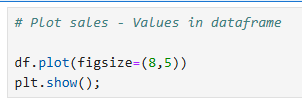

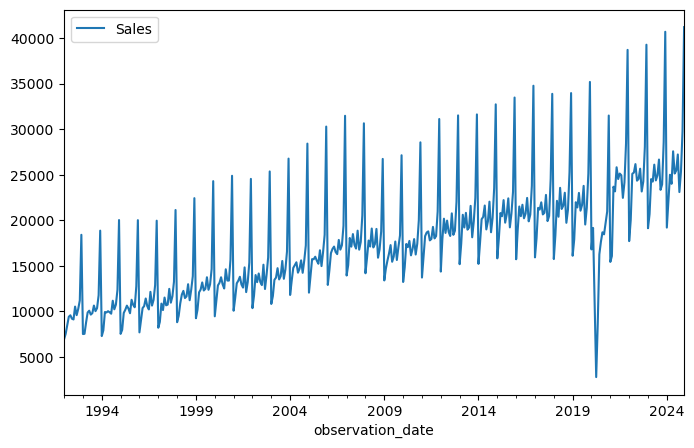

In [83]:
df.plot(figsize=(8,5))
plt.show()

____________________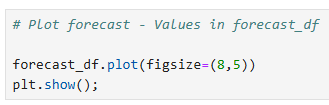

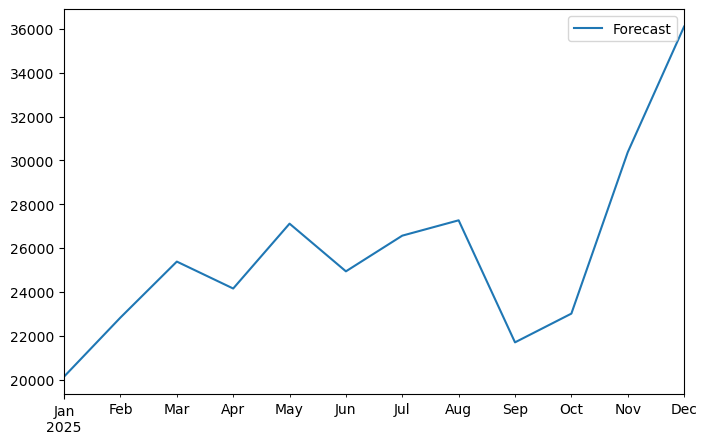

In [84]:
forecast_df.plot(figsize=(8,5))
plt.show()

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________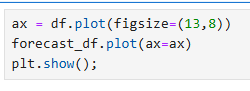

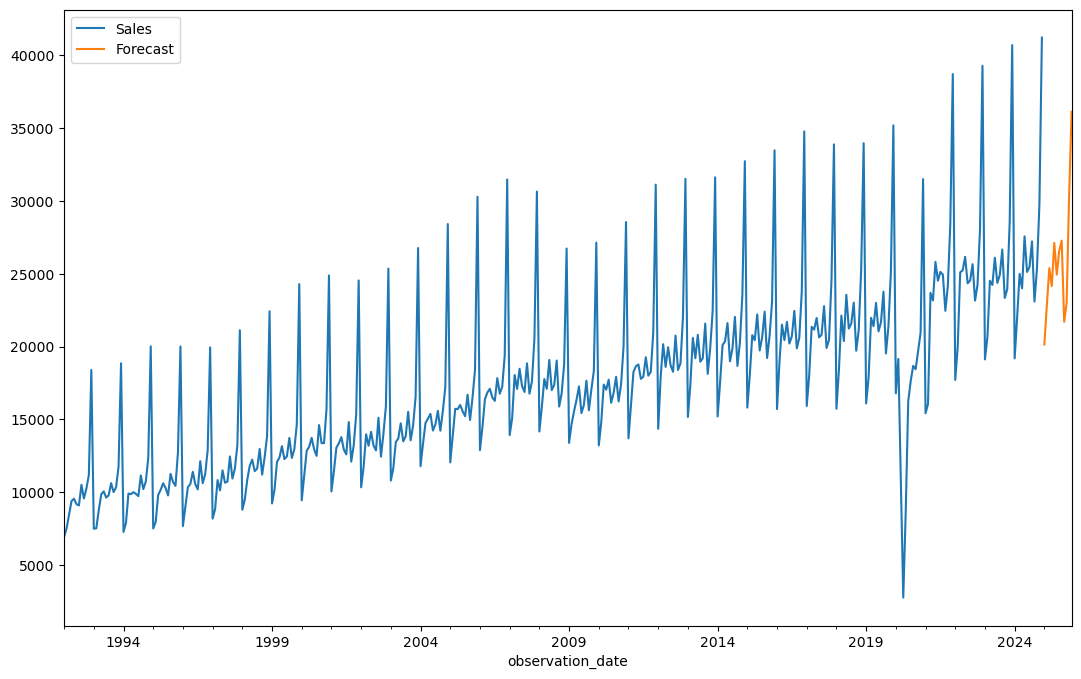

In [85]:
ax = df.plot(figsize=(13,8))
forecast_df.plot(ax=ax)
plt.show()

_______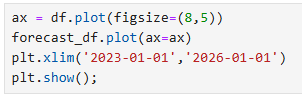

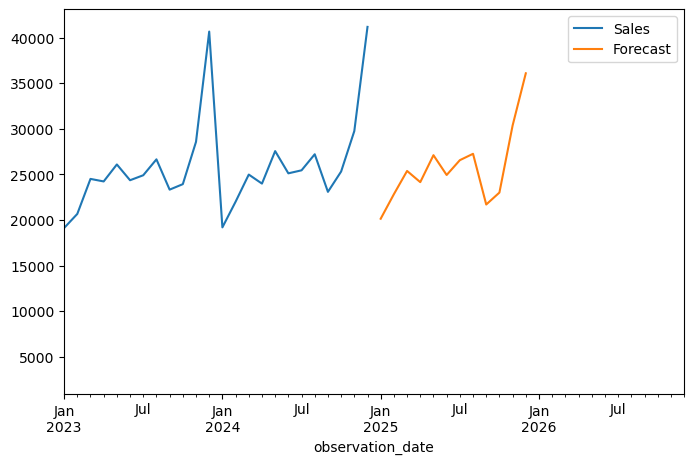

In [86]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01', '2026-12-01')
plt.show()

### Cecking Forecast for last 12 months

<html> <h4 style="font-style:italic; color:blue;"> Just run the 3 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [87]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[us]', freq='MS')

In [88]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
                           columns=['Forecast'])

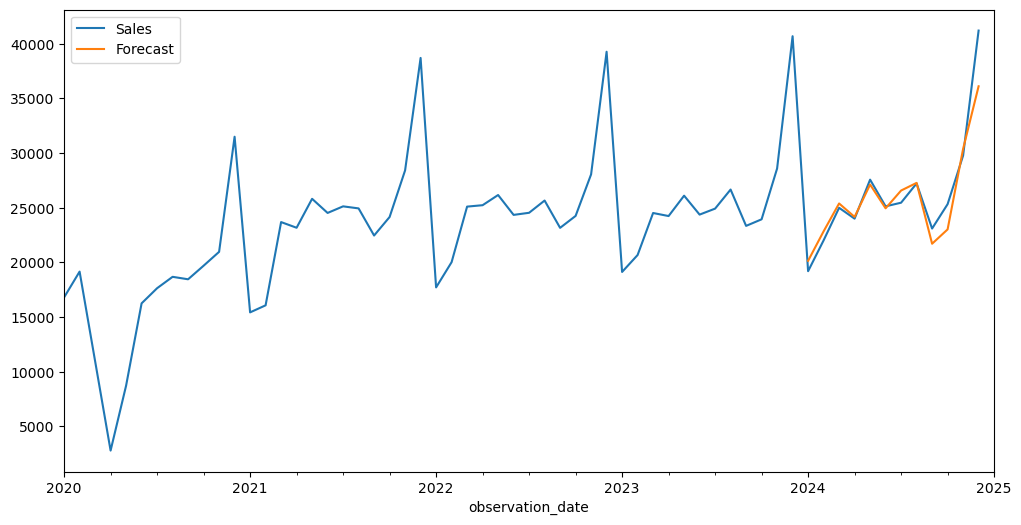

In [89]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show();

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the 2nd model's summary

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Please record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### Try the same example with a LSTM and GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!